In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
# Veriyi yükleme
file_path = "Bares_T35.xlsx"
df = pd.read_excel(file_path, sheet_name="Bares_T35")

In [10]:
df.head()

,Unnamed: 0,BRS.T35_N_ROT_PLC,BRS.T35_Power,BRS.T35_T_GBX_OIL_1,BRS.T35_T_GBX_OIL_2,BRS.T35_T_GBX_T1_HSS,BRS.T35_T_GBX_T1_IMS,BRS.T35_T_GBX_T3_HSS,BRS.T35_T_GBX_T3_IMS,BRS.T35_T_GEAR_BEAR,BRS.T35_Temp_Ambient,BRS.T35_WIND_DIR,BRS.T35_Wind_speed
0,2024-01-25T00:00:00.000,NaN,544.650024,55.150002,58.610001,56.509998,52.779999,61.220001,57.910000,61.220001,5.00,101.000000,6.28
1,2024-01-25T00:10:00.000,NaN,420.470001,54.810001,57.990002,56.080002,52.410000,60.650002,57.439999,60.650002,4.09,93.879997,5.80
2,2024-01-25T00:20:00.000,NaN,404.429993,54.480000,57.490002,55.650002,52.029999,60.090000,56.959999,60.090000,5.00,103.050003,5.82
3,2024-01-25T00:30:00.000,NaN,344.700012,54.139999,56.980000,55.209999,51.660000,59.520000,56.490002,59.520000,5.00,96.570000,5.09
4,2024-01-25T00:40:00.000,NaN,157.369995,53.799999,56.470001,54.779999,51.279999,58.950001,56.020000,58.950001,5.00,104.849998,4.67


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57024 entries, 0 to 57023
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            57024 non-null  object 
 1   BRS.T35_N_ROT_PLC     37692 non-null  float64
 2   BRS.T35_Power         56003 non-null  float64
 3   BRS.T35_T_GBX_OIL_1   55991 non-null  float64
 4   BRS.T35_T_GBX_OIL_2   55992 non-null  float64
 5   BRS.T35_T_GBX_T1_HSS  55995 non-null  float64
 6   BRS.T35_T_GBX_T1_IMS  56000 non-null  float64
 7   BRS.T35_T_GBX_T3_HSS  55989 non-null  float64
 8   BRS.T35_T_GBX_T3_IMS  55975 non-null  float64
 9   BRS.T35_T_GEAR_BEAR   55989 non-null  float64
 10  BRS.T35_Temp_Ambient  56003 non-null  float64
 11  BRS.T35_WIND_DIR      56600 non-null  float64
 12  BRS.T35_Wind_speed    56003 non-null  float64
dtypes: float64(12), object(1)
memory usage: 5.7+ MB


In [14]:
print(df.isna().sum())

Unnamed: 0                  0
BRS.T35_N_ROT_PLC       19332
BRS.T35_Power            1021
BRS.T35_T_GBX_OIL_1      1033
BRS.T35_T_GBX_OIL_2      1032
BRS.T35_T_GBX_T1_HSS     1029
BRS.T35_T_GBX_T1_IMS     1024
BRS.T35_T_GBX_T3_HSS     1035
BRS.T35_T_GBX_T3_IMS     1049
BRS.T35_T_GEAR_BEAR      1035
BRS.T35_Temp_Ambient     1021
BRS.T35_WIND_DIR          424
BRS.T35_Wind_speed       1021
dtype: int64


In [16]:
df.describe()

,BRS.T35_N_ROT_PLC,BRS.T35_Power,BRS.T35_T_GBX_OIL_1,BRS.T35_T_GBX_OIL_2,BRS.T35_T_GBX_T1_HSS,BRS.T35_T_GBX_T1_IMS,BRS.T35_T_GBX_T3_HSS,BRS.T35_T_GBX_T3_IMS,BRS.T35_T_GEAR_BEAR,BRS.T35_Temp_Ambient,BRS.T35_WIND_DIR,BRS.T35_Wind_speed
count,37692.000000,56003.000000,55991.000000,55992.000000,55995.000000,56000.000000,55989.000000,55975.000000,55989.000000,56003.000000,56600.000000,56003.000000
mean,8.672092,955.025030,51.430494,53.151802,51.427798,50.069093,55.328743,53.354610,55.330465,16.483949,154.149550,7.623761
std,5.267102,990.291452,10.457859,12.367036,12.494590,10.800841,13.034929,10.938164,13.031296,7.969305,81.039150,3.733592
min,0.000000,-387.119995,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-139.000000,0.000000
25%,3.310000,2.520000,45.315001,45.000000,41.000000,42.820000,46.060001,47.000000,46.060001,10.535000,102.910004,4.900000
50%,10.580000,592.820007,52.220001,54.919998,54.700001,51.830002,58.000000,54.240002,58.000000,16.000000,112.000000,7.430000
75%,13.260000,1670.849976,60.130001,63.869999,62.099998,59.450001,67.029999,62.630001,67.029999,23.000000,245.929993,10.300000
max,16.049999,2857.959961,72.000000,75.860001,75.830002,71.000000,78.790001,74.870003,78.790001,39.910000,515.000000,21.420000


In [19]:
# Zaman sütununu datetime formatına çevirme (Eğer zaman sütunu varsa)
df.rename(columns={'Unnamed: 0': 'Timestamp'}, inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# rot_plc değişkeni
target_col = "BRS.T35_N_ROT_PLC"

In [21]:
# 1. Rot_PLC dışındaki sütunlara 20 pencere genişliği ile rolling mean uygulama
df.iloc[:, 2:] = df.iloc[:, 2:].rolling(window=20, min_periods=1).mean()


In [23]:
# 2. Kalan boş değerleri lineer interpolasyon ile doldurma
df.iloc[:, 2:] = df.iloc[:, 2:].interpolate(method='linear')

In [25]:
# 3. ROT_PLC değişkenindeki boş değerleri regresyon modeliyle doldurma
# Boş olmayan verilerle model eğitme
df_non_null = df.dropna(subset=[target_col])  # Rot_PLC'si dolu olan satırlar
df_null = df[df[target_col].isna()]  # Rot_PLC'si boş olan satırlar

X_train = df_non_null.drop(columns=[target_col, 'Timestamp'])
y_train = df_non_null[target_col]

X_test = df_null.drop(columns=[target_col, 'Timestamp'])

In [27]:
# Regresyon modelini oluşturma ve eğitme
model = LinearRegression()
model.fit(X_train, y_train)

# Eksik rot_plc değerlerini tahmin etme
df.loc[df[target_col].isna(), target_col] = model.predict(X_test)

# İlk birkaç satırı yazdırma
df.head()


,Timestamp,BRS.T35_N_ROT_PLC,BRS.T35_Power,BRS.T35_T_GBX_OIL_1,BRS.T35_T_GBX_OIL_2,BRS.T35_T_GBX_T1_HSS,BRS.T35_T_GBX_T1_IMS,BRS.T35_T_GBX_T3_HSS,BRS.T35_T_GBX_T3_IMS,BRS.T35_T_GEAR_BEAR,BRS.T35_Temp_Ambient,BRS.T35_WIND_DIR,BRS.T35_Wind_speed
0,2024-01-25 00:00:00,10.742684,544.650024,55.150002,58.610001,56.509998,52.779999,61.220001,57.910000,61.220001,5.000000,101.000000,6.280000
1,2024-01-25 00:10:00,10.480758,482.560013,54.980001,58.300001,56.295000,52.594999,60.935001,57.674999,60.935001,4.545000,97.439999,6.040000
2,2024-01-25 00:20:00,10.345013,456.516673,54.813334,58.030001,56.080001,52.406666,60.653334,57.436666,60.653334,4.696667,99.310000,5.966667
3,2024-01-25 00:30:00,10.218544,428.562508,54.645000,57.767501,55.862500,52.219999,60.370001,57.200000,60.370001,4.772500,98.625000,5.747500
4,2024-01-25 00:40:00,10.038233,374.324005,54.476000,57.508001,55.646000,52.031999,60.086001,56.964000,60.086001,4.818000,99.870000,5.532000


In [31]:
df.isna().sum()

Timestamp               0
BRS.T35_N_ROT_PLC       0
BRS.T35_Power           0
BRS.T35_T_GBX_OIL_1     0
BRS.T35_T_GBX_OIL_2     0
BRS.T35_T_GBX_T1_HSS    0
BRS.T35_T_GBX_T1_IMS    0
BRS.T35_T_GBX_T3_HSS    0
BRS.T35_T_GBX_T3_IMS    0
BRS.T35_T_GEAR_BEAR     0
BRS.T35_Temp_Ambient    0
BRS.T35_WIND_DIR        0
BRS.T35_Wind_speed      0
dtype: int64

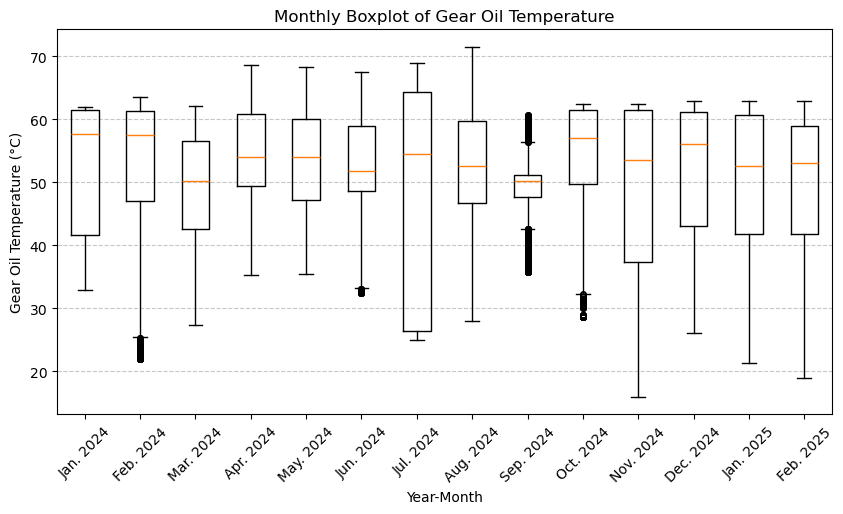

In [33]:
# 2) Tarih sütunu kontrol ve düzenleme
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['Year-Month'] = df['Timestamp'].dt.strftime('%b. %Y')  # "Jan. 2018", "Feb. 2018" formatı için
else:
    raise ValueError("Timestamp kolonu bulunamadı! Lütfen veri setinde 'timestamp' olduğunu kontrol edin.")

# 3) Aylara göre sıralama (Örneğin: "Jan. 2018" → "Dec. 2018")
months_sorted = sorted(df['Year-Month'].unique(), key=lambda x: pd.to_datetime(x, format='%b. %Y'))

# 4) Her ay için gear oil temperature verilerini gruplama
if 'BRS.T35_T_GBX_OIL_1' in df.columns:
    data_for_boxplot = [df.loc[df['Year-Month'] == month, 'BRS.T35_T_GBX_OIL_1'].values for month in months_sorted]
else:
    raise ValueError("'oil_temperature' kolonu veri setinde bulunamadı!")

# 5) Boxplot çizimi
plt.figure(figsize=(10, 5))
plt.boxplot(data_for_boxplot, labels=months_sorted, showfliers=True, flierprops=dict(marker='o', color='red', markersize=4))

# 6) Grafik detayları
plt.xticks(rotation=45)  # X ekseni yazılarını döndürme
plt.xlabel('Year-Month')
plt.ylabel('Gear Oil Temperature (°C)')
plt.title('Monthly Boxplot of Gear Oil Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7) Görselleştirme
plt.show()

In [35]:
for col in df.columns:
    print("-", col)

- Timestamp
- BRS.T35_N_ROT_PLC
- BRS.T35_Power
- BRS.T35_T_GBX_OIL_1
- BRS.T35_T_GBX_OIL_2
- BRS.T35_T_GBX_T1_HSS
- BRS.T35_T_GBX_T1_IMS
- BRS.T35_T_GBX_T3_HSS
- BRS.T35_T_GBX_T3_IMS
- BRS.T35_T_GEAR_BEAR
- BRS.T35_Temp_Ambient
- BRS.T35_WIND_DIR
- BRS.T35_Wind_speed
- Year-Month


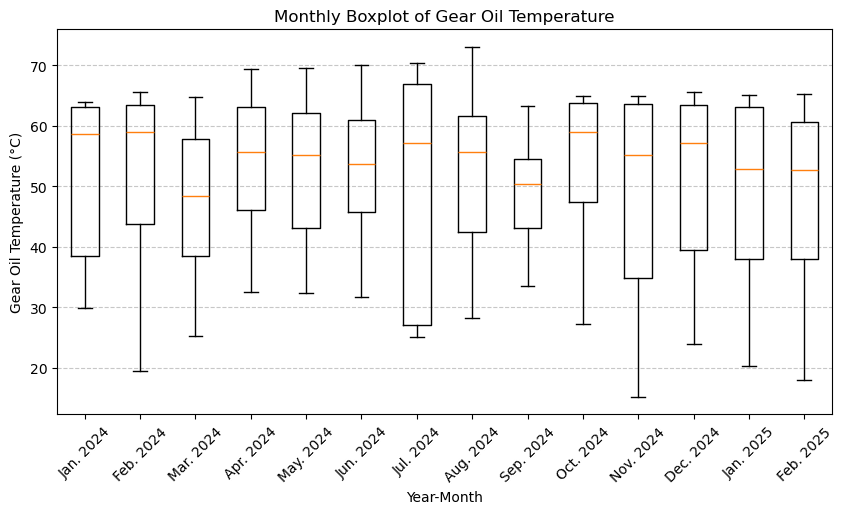

In [37]:
if 'BRS.T35_T_GBX_T1_HSS' in df.columns:
    data_for_boxplot = [df.loc[df['Year-Month'] == month, 'BRS.T35_T_GBX_T1_HSS'].values for month in months_sorted]
else:
    raise ValueError("'BRS.T35_T_GBX_T1_HSS' kolonu veri setinde bulunamadı!")

# 5) Boxplot çizimi
plt.figure(figsize=(10, 5))
plt.boxplot(data_for_boxplot, labels=months_sorted, showfliers=True, flierprops=dict(marker='o', color='red', markersize=4))

# 6) Grafik detayları
plt.xticks(rotation=45)  # X ekseni yazılarını döndürme
plt.xlabel('Year-Month')
plt.ylabel('Gear Oil Temperature (°C)')
plt.title('Monthly Boxplot of Gear Oil Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7) Görselleştirme
plt.show()

In [39]:
timestamp_column = None
for col in df.columns:
    if "timestamp" in col.lower() or "date" in col.lower():
        timestamp_column = col
        break

if timestamp_column:
    df[timestamp_column] = pd.to_datetime(df[timestamp_column], errors='coerce')
    df['Year-Month'] = df[timestamp_column].dt.strftime('%b. %Y')  # "Jan. 2018", "Feb. 2018"
else:
    raise ValueError("Tarih içeren bir sütun bulunamadı! Lütfen veri setinde 'timestamp' veya benzeri bir sütun olup olmadığını kontrol edin.")

# 3) Aylara göre sıralama
months_sorted = sorted(df['Year-Month'].unique(), key=lambda x: pd.to_datetime(x, format='%b. %Y'))

# 4) Sayısal değişkenleri belirleme (Tarih sütunu ve kategorik değişkenleri hariç tutarak)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

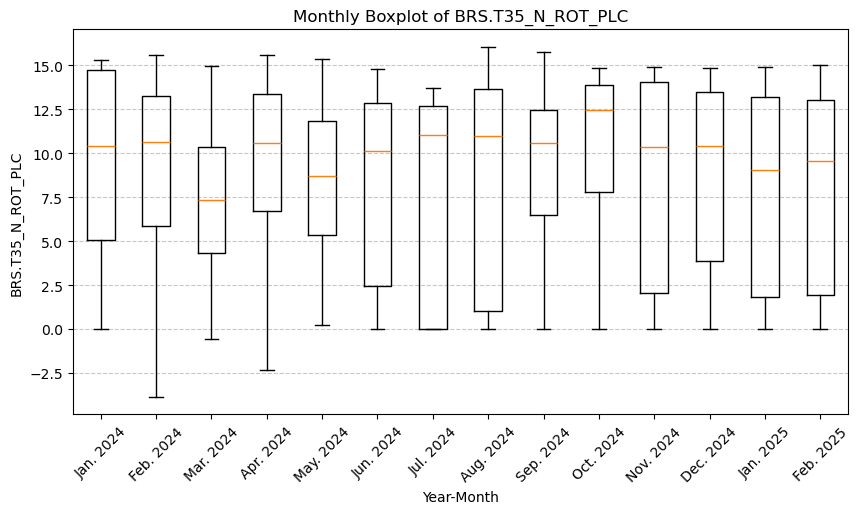

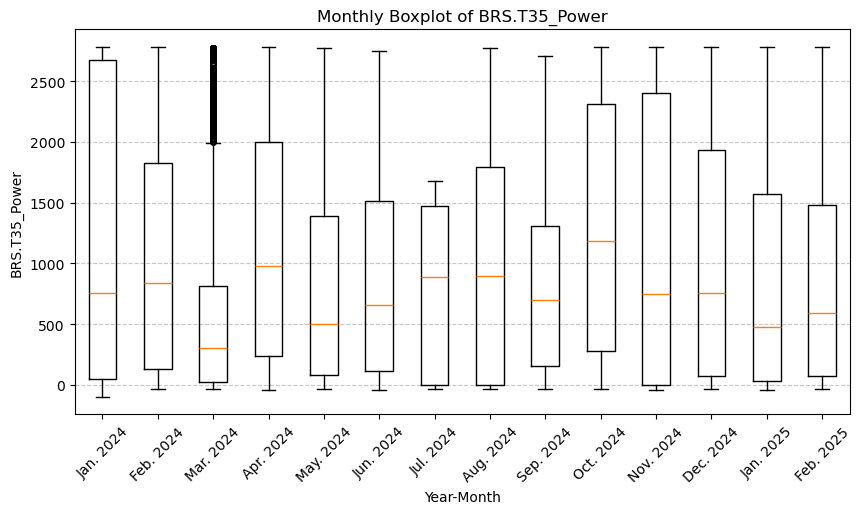

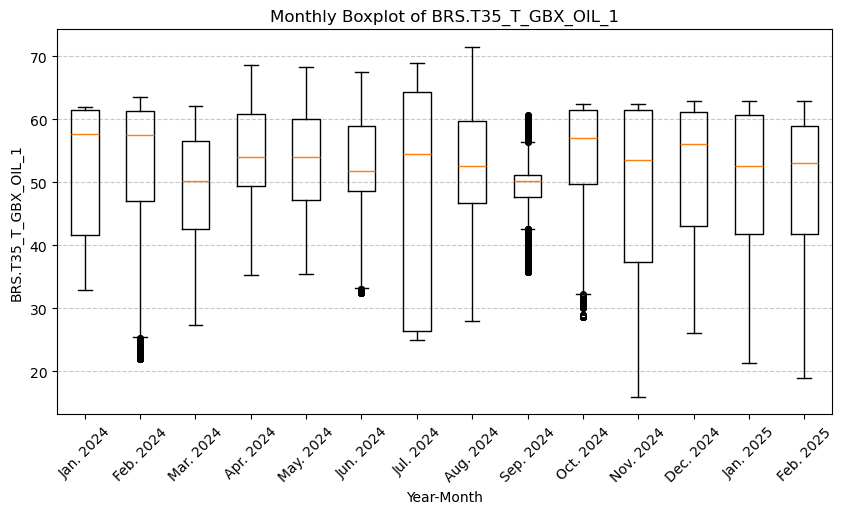

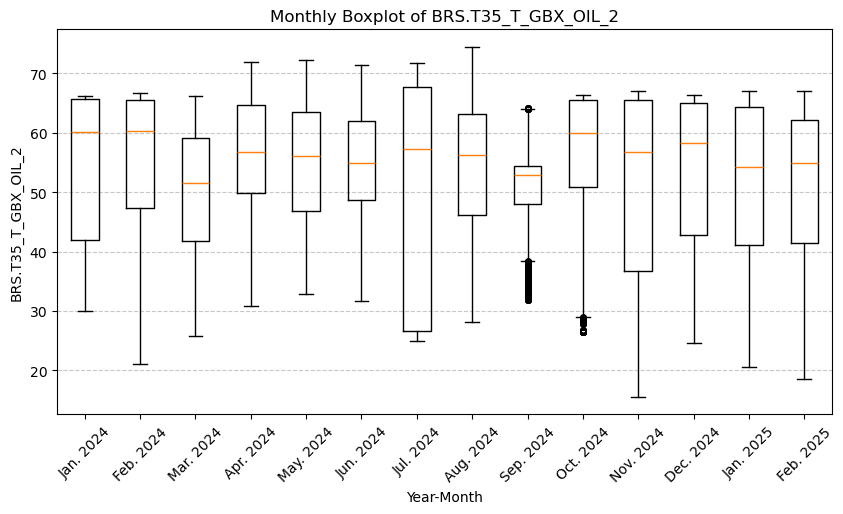

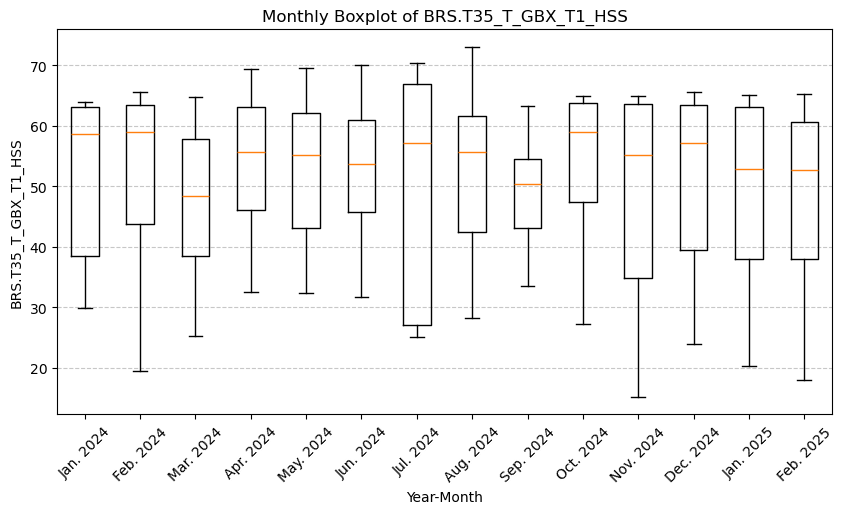

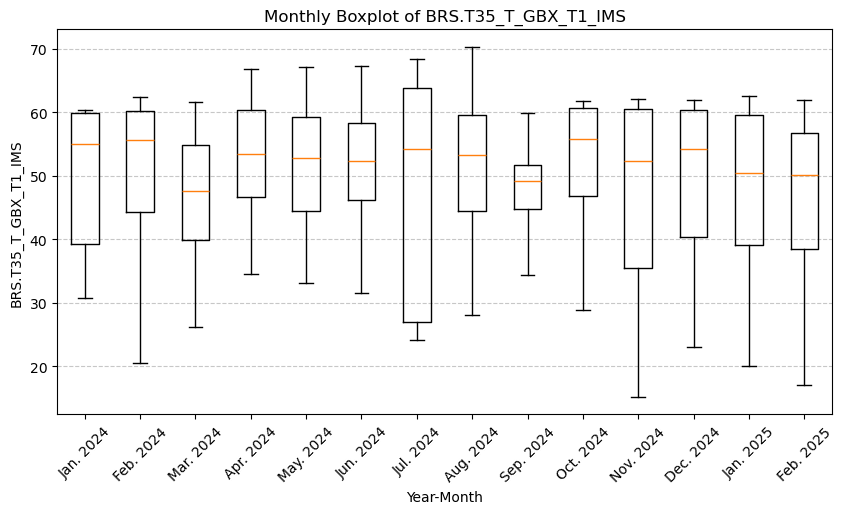

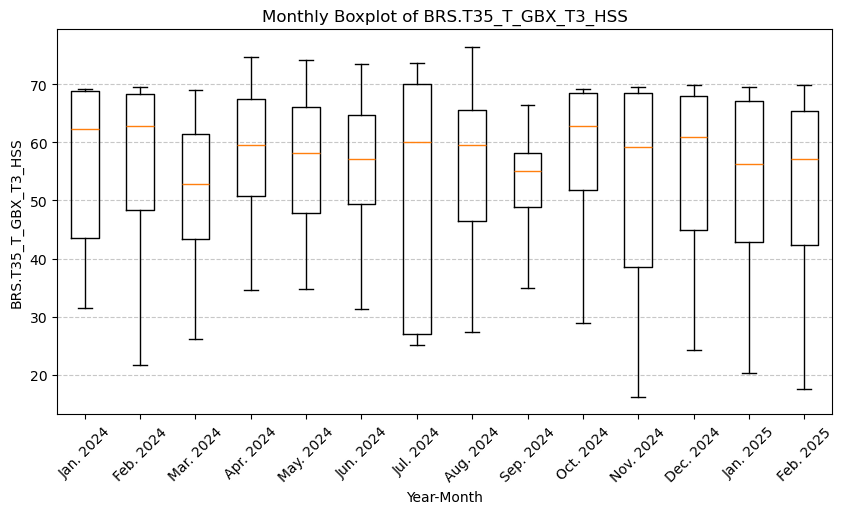

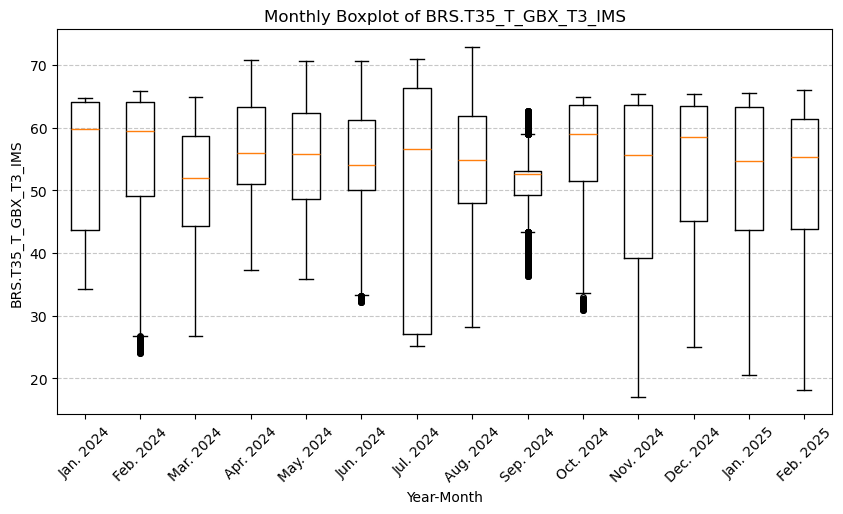

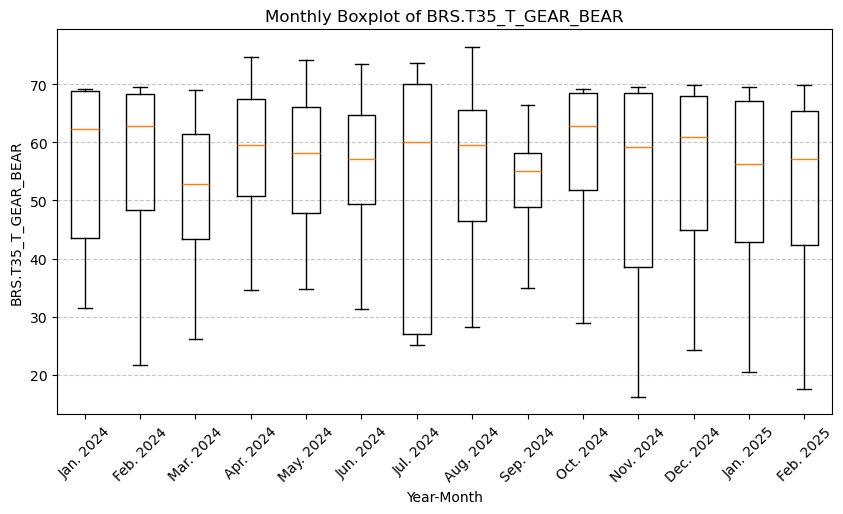

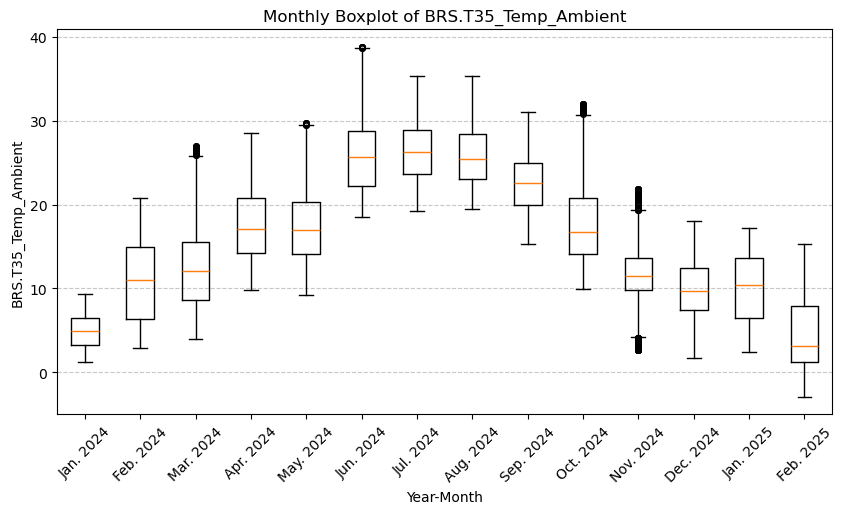

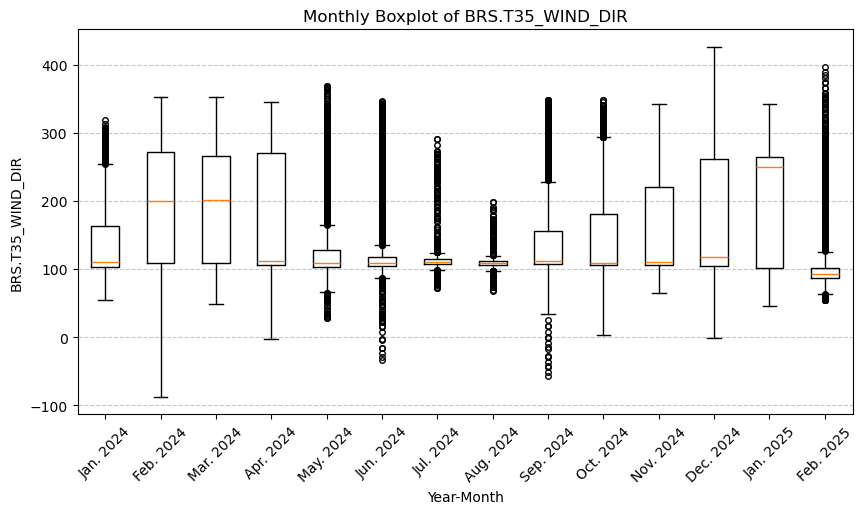

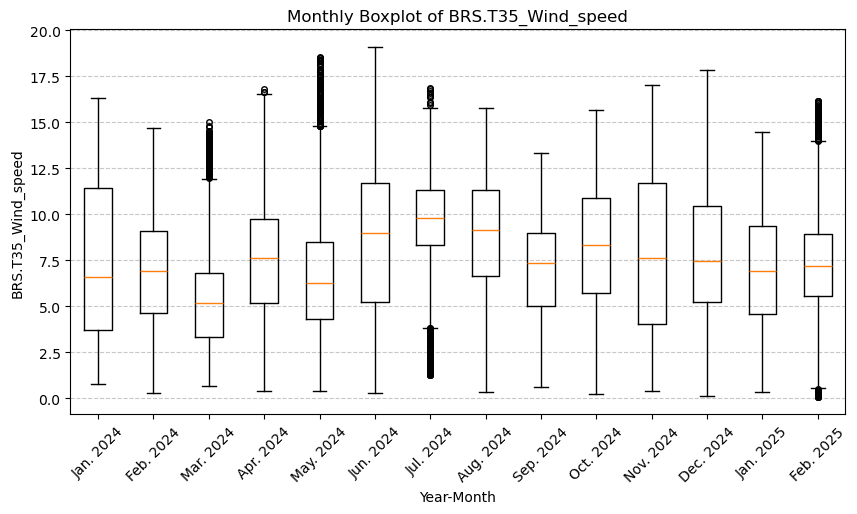

In [41]:
# 5) Tüm sayısal değişkenler için döngü
for var in numeric_cols:
    if var in df.columns:  # Eğer ilgili kolon gerçekten varsa işlem yap
        data_for_boxplot = [df.loc[df['Year-Month'] == month, var].values for month in months_sorted]
        
        # Boxplot çizimi
        plt.figure(figsize=(10, 5))
        plt.boxplot(data_for_boxplot, labels=months_sorted, showfliers=True, flierprops=dict(marker='o', color='red', markersize=4))

        # Grafik detayları
        plt.xticks(rotation=45)  # X ekseni yazılarını döndürme
        plt.xlabel('Year-Month')
        plt.ylabel(var)  # Değişken adını Y eksenine koy
        plt.title(f'Monthly Boxplot of {var}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Görselleştirme
        plt.show()

In [46]:
df.head()

,Timestamp,BRS.T35_N_ROT_PLC,BRS.T35_Power,BRS.T35_T_GBX_OIL_1,BRS.T35_T_GBX_OIL_2,BRS.T35_T_GBX_T1_HSS,BRS.T35_T_GBX_T1_IMS,BRS.T35_T_GBX_T3_HSS,BRS.T35_T_GBX_T3_IMS,BRS.T35_T_GEAR_BEAR,BRS.T35_Temp_Ambient,BRS.T35_WIND_DIR,BRS.T35_Wind_speed,Year-Month
0,2024-01-25 00:00:00,10.742684,544.650024,55.150002,58.610001,56.509998,52.779999,61.220001,57.910000,61.220001,5.000000,101.000000,6.280000,Jan. 2024
1,2024-01-25 00:10:00,10.480758,482.560013,54.980001,58.300001,56.295000,52.594999,60.935001,57.674999,60.935001,4.545000,97.439999,6.040000,Jan. 2024
2,2024-01-25 00:20:00,10.345013,456.516673,54.813334,58.030001,56.080001,52.406666,60.653334,57.436666,60.653334,4.696667,99.310000,5.966667,Jan. 2024
3,2024-01-25 00:30:00,10.218544,428.562508,54.645000,57.767501,55.862500,52.219999,60.370001,57.200000,60.370001,4.772500,98.625000,5.747500,Jan. 2024
4,2024-01-25 00:40:00,10.038233,374.324005,54.476000,57.508001,55.646000,52.031999,60.086001,56.964000,60.086001,4.818000,99.870000,5.532000,Jan. 2024


In [50]:
# 3. Sıcaklık sütunlarını ortalama alarak tek bir sütuna indirgeme
temperature_columns = [
    "BRS.T35_T_GBX_OIL_1",
    "BRS.T35_T_GBX_OIL_2",
    "BRS.T35_T_GBX_T1_HSS",
    "BRS.T35_T_GBX_T1_IMS",
    "BRS.T35_T_GBX_T3_HSS",
    "BRS.T35_T_GBX_T3_IMS"
]

df["BRS.T35_T_GBX_Avg"] = df[temperature_columns].mean(axis=1)

# Orijinal sıcaklık sütunlarını kaldırma
df = df.drop(columns=temperature_columns)
df = df.drop(columns="Year-Month")

In [52]:
df.head()

,Timestamp,BRS.T35_N_ROT_PLC,BRS.T35_Power,BRS.T35_T_GEAR_BEAR,BRS.T35_Temp_Ambient,BRS.T35_WIND_DIR,BRS.T35_Wind_speed,BRS.T35_T_GBX_Avg
0,2024-01-25 00:00:00,10.742684,544.650024,61.220001,5.000000,101.000000,6.280000,57.030000
1,2024-01-25 00:10:00,10.480758,482.560013,60.935001,4.545000,97.439999,6.040000,56.796667
2,2024-01-25 00:20:00,10.345013,456.516673,60.653334,4.696667,99.310000,5.966667,56.570000
3,2024-01-25 00:30:00,10.218544,428.562508,60.370001,4.772500,98.625000,5.747500,56.344167
4,2024-01-25 00:40:00,10.038233,374.324005,60.086001,4.818000,99.870000,5.532000,56.118667


In [37]:
df.to_csv("Bares_T35_cleaned_data.csv", index=True)

C:\Users\90551\AppData\Local\Temp\ipykernel_7936\1472886291.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].fillna(method='ffill').fillna(method='bfill')


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 45619, number of used features: 6
[LightGBM] [Info] Start training from score 52.501106
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

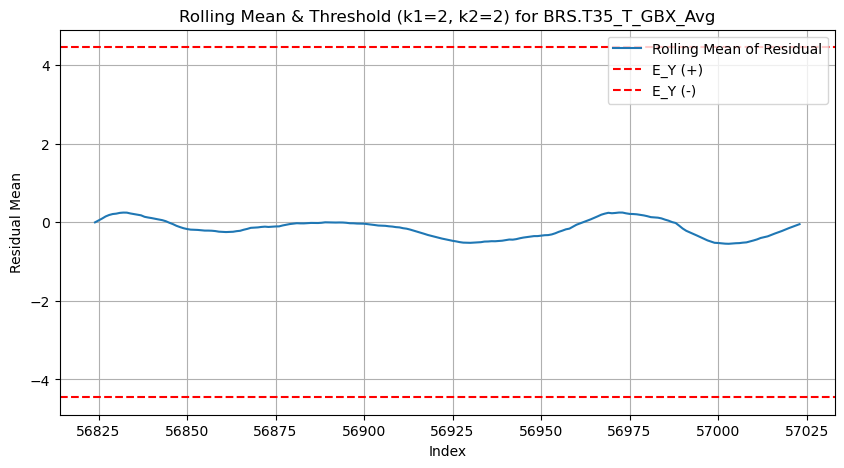

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import lightgbm as lgb

# -------------------------------------------------------
# 1) Veri setinin (df) yüklü olduğunu varsayıyoruz:
#    Örn: df = pd.read_csv("/mnt/data/Bares_T35_cleaned_data.csv")
# -------------------------------------------------------

# Hedef sütun (gearbox average temperature)
target_col = 'BRS.T35_T_GBX_Avg'
if target_col not in df.columns:
    raise ValueError(f"'{target_col}' kolonu veri setinde bulunamadı!")

# Örnek amaçlı: Feature (giriş) sütunları seçiyoruz
# Kendi veri setinizde, MODELDE KULLANACAĞINIZ sütunları belirleyin
# Bu örnekte birkaç sütunu random seçtik, gerçekte projenize uygun sütunları ayarlayın
possible_features = [col for col in df.columns 
                     if col not in [target_col, 'Timestamp', 'Date', 'ID']]  # var ise hariç tutulanlar

# Eğer hiç feature kalmazsa, en azından 1-2 sütun eklemelisiniz
if not possible_features:
    raise ValueError("Feature olarak kullanılacak uygun sütun bulunamadı. Lütfen feature sütunları belirleyin.")

# Birkaç feature seçelim (örnek)
# Gerçekte hangi sütunların tahmin için en anlamlı olduğunu domain bilginize göre seçmelisiniz
feature_cols = possible_features  

# Eksik değerlere dikkat edin, basitçe doldurabiliriz (ya da veri temizliği yapılmalı)
df[feature_cols] = df[feature_cols].fillna(method='ffill').fillna(method='bfill')

X = df[feature_cols]
y = df[target_col]

# 2) Train-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# 3) LightGBM Modelinin Eğitimi
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
lgb_model.fit(X_train, y_train)

# 4) Tahminler (Prediction) ve Artık (Residual) Hesabı
df['prediction'] = lgb_model.predict(X)  # Tüm veri seti için tahmin
df['residual']   = df[target_col] - df['prediction']

# 5) Hareketli Pencere Ortalaması ve Std (Rolling Window)
window_size = 30  # Örneğin 30 veri noktası
df['res_mean'] = df['residual'].rolling(window=window_size).mean()
df['res_std']  = df['residual'].rolling(window=window_size).std()

# ------------------------------------------------------------
# 2. Makalede (31) ve (32) No'lu Denklem: Eşik Değerleri
# ------------------------------------------------------------
# E_V = max(|res_mean|)
# S_V = max(res_std)
E_V = df['res_mean'].abs().max(skipna=True)  # mutlak ortalama artıkların en büyüğü
S_V = df['res_std'].max(skipna=True)         # artıkların std'sinin en büyüğü

# E_Y = k1 * E_V, S_Y = k2 * S_V (k1 = 2, k2 = 2)
k1, k2 = 2, 2
E_Y = k1 * E_V
S_Y = k2 * S_V

print(f"E_V (max abs mean): {E_V:.4f}")
print(f"S_V (max std): {S_V:.4f}")
print(f"E_Y (mean threshold): {E_Y:.4f}")
print(f"S_Y (std threshold): {S_Y:.4f}")

# ------------------------------------------------------------
# 3. Alarm Koşulları
# ------------------------------------------------------------
# Orta Öncelikli Alarm: res_mean veya res_std eşiği aşıyorsa
df['alarm_medium'] = (
    (df['res_mean'].abs() > E_Y) |
    (df['res_std'] > S_Y)
)

# Yüksek Öncelikli Alarm: res_mean ve res_std ikisi birden eşiği aşıyorsa
df['alarm_high'] = (
    (df['res_mean'].abs() > E_Y) &
    (df['res_std'] > S_Y)
)

# ------------------------------------------------------------
# 4. Çıktı ve Örnek İnceleme
# ------------------------------------------------------------
print("\nSon 10 Satır (Rolling Mean, Rolling Std, Alarmlar):")
print(df[['res_mean', 'res_std', 'alarm_medium', 'alarm_high']].tail(10))

# ------------------------------------------------------------
# 5. (İsteğe Bağlı) Görselleştirme
# ------------------------------------------------------------
# Rolling Mean - E_Y Eşik Gösterimi
subset = df.tail(200)  # son 200 satırlık veri
plt.figure(figsize=(10,5))
plt.plot(subset.index, subset['res_mean'], label='Rolling Mean of Residual')
plt.axhline(y= E_Y,  color='red', linestyle='--', label='E_Y (+)')
plt.axhline(y=-E_Y,  color='red', linestyle='--', label='E_Y (-)')
plt.xlabel('Index')
plt.ylabel('Residual Mean')
plt.title(f'Rolling Mean & Threshold (k1=2, k2=2) for {target_col}')
plt.legend()
plt.grid(True)
plt.show()
